<a href="https://colab.research.google.com/github/aliawan7november/Encapsulation/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PART 1: LINE INTEGRAL ---
Approximate value of line integral: 1.0015010004999993

--- PART 2: FOURIER SERIES ---
a0 coefficient: 0.0
n = 1 | an = -0.0000, bn = 1.0000
n = 2 | an = 0.0000, bn = 0.0000
n = 3 | an = 0.0000, bn = 0.0000
n = 4 | an = 0.0000, bn = -0.0000


/tmp/ipykernel_10407/3583102760.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  a0 = (1 / np.pi) * np.trapz(f(x), x)
/tmp/ipykernel_10407/3583102760.py:61: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  an = (1 / np.pi) * np.trapz(f(x) * np.cos(n * x), x)
/tmp/ipykernel_10407/3583102760.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bn = (1 / np.pi) * np.trapz(f(x) * np.sin(n * x), x)


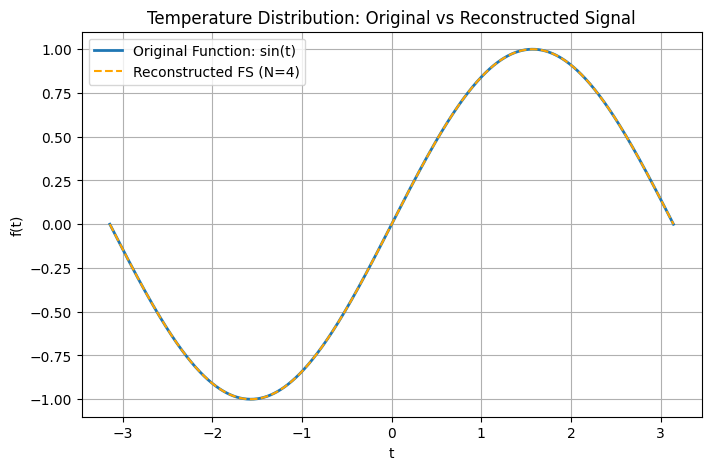

In [7]:
#Name: M. Ali Awan
#Roll No: Sp23/BSCS/149

import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# PART 1: Line Integral Approximation
# =====================================================================
print("--- PART 1: LINE INTEGRAL ---")

# Parameter t ranges from 0 to 1 based on 0 <= x <= 1
t = np.linspace(0, 1, 1000)

# Parametrization of the curve y = x^2 from (0,0) to (1,1)
x = t
y = t**2

# Numerical derivatives using np.gradient
dx = np.gradient(x, t)
dy = np.gradient(y, t)

# Vector field components for F(x, y) = y*i + x*j
F1 = y
F2 = x

# Line integral: F.dr = F1*dx + F2*dy
integrand = F1 * dx + F2 * dy

# Numerical integration calculation
line_integral_val = np.sum(integrand * (t[1] - t[0]))

print(f"Approximate value of line integral: {line_integral_val}\n")


# =====================================================================
# PART 2: Fourier Series Coefficients & Signal Reconstruction
# =====================================================================
print("--- PART 2: FOURIER SERIES ---")

# Number of Fourier terms requested: First 4 coefficients (n = 1 to 4)
N = 4

# Domain from -pi to pi as specified in the problem statement
x_domain = np.linspace(-np.pi, np.pi, 1000)

# Target signal function: f(t) = sin(t)
def f(x):
    return np.sin(x)

# Numerical Fourier Series Calculation using np.trapz
def fourier_series_numeric(f, x, N):
    # DC component calculation
    a0 = (1 / np.pi) * np.trapz(f(x), x)
    print(f"a0 coefficient: {a0}")

    result = a0 / 2

    # Calculate an and bn coefficients iteratively
    for n in range(1, N + 1):
        an = (1 / np.pi) * np.trapz(f(x) * np.cos(n * x), x)
        bn = (1 / np.pi) * np.trapz(f(x) * np.sin(n * x), x)

        print(f"n = {n} | an = {an:.4f}, bn = {bn:.4f}")

        # Add the matching terms to the reconstructed signal
        result += an * np.cos(n * x) + bn * np.sin(n * x)

    return result

# Compute the actual values
y_original = f(x_domain)
y_reconstructed = fourier_series_numeric(f, x_domain, N)


# =====================================================================
# PART 3: Plotting and Visualization
# =====================================================================
plt.figure(figsize=(8, 5))

# Plot original vs reconstructed function
plt.plot(x_domain, y_original, label="Original Function: sin(t)", linewidth=2)
plt.plot(x_domain, y_reconstructed, '--', label=f"Reconstructed FS (N={N})", color="orange")

# Formatting elements match slide style guide
plt.title("Temperature Distribution: Original vs Reconstructed Signal")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()